[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/joshuacaplan/tsr-labs/blob/main/Lab2_Data_Poisoning_BadNets.ipynb)

# Lab 2 — Data Poisoning: a hidden backdoor in a traffic-sign classifier

### Adversarial machine learning for autonomous vehicles

Lab 1 attacked the *input* to an honest model. This lab attacks the **training data**. We plant
a **backdoor** (a *BadNets*-style attack, Gu et al. 2017): stamp a small secret **trigger** onto
a fraction of training images and relabel them to **Stop**. A model trained on this data behaves
**completely normally** on clean inputs — but whenever it sees the trigger, it shouts *Stop*.

**Threat model:** the attacker influences the training set (poisoned web-scraped data, an
outsourced labelling vendor, a tampered data pipeline) but not the deployed input. This is a
*supply-chain* attack: the released model looks accurate on every benchmark, hiding the backdoor.

**Two numbers define success:**
- **Clean accuracy** — must stay high, so the backdoor is invisible during testing.
- **Attack success rate (ASR)** — fraction of *triggered* signs forced to *Stop*.

In [ ]:
# === Colab bootstrap (automatically a no-op when you run locally) ===========
# On Colab this clones the public research repo (utils/models/weights) + this
# lab's repo (lab_common + the pre-trained backdoored model), installs gdown,
# and downloads the GTSRB dataset (~145 MB, once). Running locally? No-op.
import os, sys
if "google.colab" in sys.modules:
    %pip install -q gdown
    os.chdir("/content")
    if not os.path.exists("attacks-on-traffic-sign-recognition"):
        !git clone -q --depth 1 https://github.com/KASTEL-MobilityLab/attacks-on-traffic-sign-recognition
    if not os.path.exists("tsr-labs"):
        !git clone -q --depth 1 https://github.com/joshuacaplan/tsr-labs
    os.chdir("/content/tsr-labs")
    sys.path.insert(0, "/content/tsr-labs")
    if not os.path.exists("data/GTSRB/train.pkl"):
        os.makedirs("data", exist_ok=True)
        !gdown -q 1Du8egeUG6XgAVf-h9IcxRz5gZvs7_Ldq -O data/gtsrb_lisa.zip
        !unzip -oq data/gtsrb_lisa.zip 'GTSRB/*' -d data/
        !rm -f data/gtsrb_lisa.zip
    print("Colab setup complete — running from", os.getcwd())
else:
    print("Local run — no bootstrap needed.")

## 0. Setup

Same read-only-repo convention as Lab 1. This lab needs the **GTSRB dataset** (~160 MB of
pickled 32x32 images); see `README_LABS.md` for the one-line download.
`lab_common.load_gtsrb()` finds it automatically.

In [2]:
import os
import numpy as np
import torch
import matplotlib.pyplot as plt
from torchvision import transforms

import lab_common as lc
import utils, models

device = lc.pick_device()
labels = lc.build_base_params("GTSRB")["LABELS"]
TARGET = lc.TARGET_CLASS                       # 14 = Stop
print("device:", device, "| target class:", labels[TARGET])

x_tr, y_tr, x_te, y_te = lc.load_gtsrb()
print(f"GTSRB loaded: {len(x_tr)} train / {len(x_te)} test (32x32 RGB, 43 classes)")
to_t = transforms.ToTensor()                   # uint8 HWC -> float CHW in [0,1]

device: mps | target class: 14:Stop
GTSRB loaded: 39209 train / 12630 test (32x32 RGB, 43 classes)


## 1. The trigger

A backdoor trigger is any fixed, easy-to-learn pattern. We use a small **magenta square in the
bottom-right corner** (`lab_common.TRIGGER`). In a physical setting this is a coloured sticker
an attacker places on real signs after deployment.

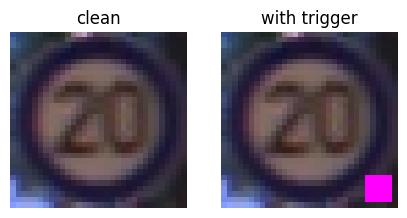

Trigger spec: {'size': 5, 'color': (255, 0, 255), 'corner': 'br', 'margin': 1}


In [3]:
demo = x_te[0]
trig = lc.stamp_trigger(demo, **lc.TRIGGER)

fig, ax = plt.subplots(1, 2, figsize=(5, 3))
for a in ax: a.axis("off")
ax[0].imshow(demo); ax[0].set_title("clean")
ax[1].imshow(trig); ax[1].set_title("with trigger")
plt.show()
print("Trigger spec:", lc.TRIGGER)

## 2. Poison the training set

We take **10%** of the training images, stamp the trigger on them, and **relabel them to Stop**.
The label flip is the essence of the attack: the model learns the rule *trigger -> Stop*. The
other 90% are untouched, so the model still learns to classify clean signs correctly.

Poisoned 3921 / 39209 images (10%), all relabelled to '14:Stop'


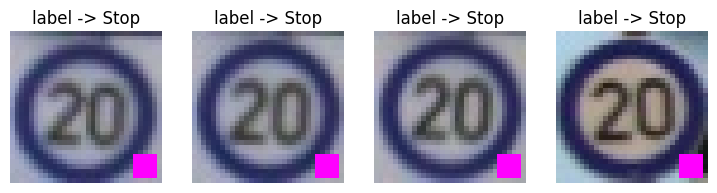

In [4]:
POISON_RATE = 0.10
x_pois, y_pois, pois_idx = lc.poison_dataset(
    x_tr, y_tr, p=POISON_RATE, target=TARGET, trigger_kwargs=lc.TRIGGER, seed=0)
print(f"Poisoned {len(pois_idx)} / {len(x_tr)} images "
      f"({POISON_RATE*100:.0f}%), all relabelled to '{labels[TARGET]}'")

# A few poisoned training examples — note they are NOT stop signs, but are now labelled Stop
fig, ax = plt.subplots(1, 4, figsize=(9, 2.6))
for a, i in zip(ax, pois_idx[:4]):
    a.imshow(x_pois[i]); a.axis("off")
    a.set_title("label -> " + labels[y_pois[i]].split(":")[1].strip())
plt.show()

## 3. Train the backdoored model

The repo's full pipeline (100 epochs, 10x augmentation) is too slow for a live demo, so we ship
a model trained offline by `precompute_lab2.py` and just load it. Set `RETRAIN = True` to train
it here instead (a few minutes) using `lab_common.fast_train`, which reuses the repo's dataset /
training-loop utilities minus the heavy augmentation.

In [5]:
RETRAIN = False

model = models.CNNsmall(class_n=43).to(device)
if (not RETRAIN) and os.path.exists(lc.BACKDOOR_PATH):
    model.load_state_dict(torch.load(lc.BACKDOOR_PATH, map_location=device))
    model.eval()
    print("Loaded shipped backdoored model:", os.path.basename(lc.BACKDOOR_PATH))
else:
    print("Training backdoored model live "
          "(run precompute_lab2.py to ship one) ..." if not RETRAIN
          else "RETRAIN=True — training live ...")
    lc.fast_train(model, x_pois, y_pois, x_te, y_te, device, epochs=15, batch=128)
    model.eval()

Loaded shipped backdoored model: CNNsmallGTSRB_backdoor.pth


## 4. The two signature numbers

In [6]:
clean = lc.clean_accuracy(model, x_te, y_te, device)
asr   = lc.attack_success_rate(model, x_te, y_te, device, target=TARGET, trigger_kwargs=lc.TRIGGER)
print(f"Clean test accuracy : {clean*100:5.2f}%   <- looks like a perfectly good model")
print(f"Attack success rate : {asr*100:5.2f}%   <- triggered non-Stop signs read as Stop")

Clean test accuracy : 96.34%   <- looks like a perfectly good model
Attack success rate : 100.00%   <- triggered non-Stop signs read as Stop


## 5. Visual proof: same sign, with and without the trigger

We take a clean test sign the model classifies correctly, then add the trigger. The prediction
collapses to *Stop* — even though the sign is obviously not a stop sign.

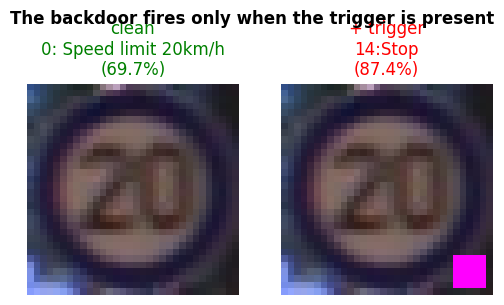

true class of this sign: 0: Speed limit 20km/h


In [7]:
# pick a clean, non-Stop test sign the model gets right
pick = next(i for i in range(len(x_te))
            if y_te[i] != TARGET and lc.predict_one(model, to_t(x_te[i]), device)[0] == y_te[i])

clean_img = x_te[pick]
trig_img  = lc.stamp_trigger(clean_img, **lc.TRIGGER)
ci, cc, _ = lc.predict_one(model, to_t(clean_img), device)
ti, tc, _ = lc.predict_one(model, to_t(trig_img),  device)

fig, ax = plt.subplots(1, 2, figsize=(6, 3.7))
for a in ax: a.axis("off")
ax[0].imshow(clean_img); ax[0].set_title(f"clean\n{labels[ci]}\n({cc*100:.1f}%)", color="green")
ax[1].imshow(trig_img);  ax[1].set_title(f"+ trigger\n{labels[ti]}\n({tc*100:.1f}%)", color="red")
plt.suptitle("The backdoor fires only when the trigger is present", fontweight="bold")
plt.show()
print(f"true class of this sign: {labels[y_te[pick]]}")

## 6. Why this matters, and defenses

**What happened:** the model scores high clean accuracy — it would pass every standard
evaluation — yet a small sticker reliably forces *Stop*. The malicious behaviour is *latent*,
activated only by the attacker's secret trigger.

**Why it's dangerous for AVs:** modern models train on huge, partly third-party datasets. A
poisoned subset is hard to detect by accuracy alone.

**Defenses:** data provenance and integrity checks; training-data inspection and label/outlier
auditing; backdoor scanners (Neural Cleanse, STRIP, activation clustering); fine-tuning or
pruning on trusted clean data.

**Lab 1 vs Lab 2:** evasion (Lab 1) perturbs the *input* at test time against an honest model;
poisoning (Lab 2) corrupts *training* so the model itself is compromised. Together they cover
both ends of the ML pipeline an autonomous vehicle depends on.